Memuat dataset

https://www.kaggle.com/datasets/camnugent/california-housing-prices?resource=download

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('housing.csv', usecols = 
['longitude', 'latitude', 'median_house_value']) 
df.head()

,longitude,latitude,median_house_value
0,-122.23,37.88,452600.0
1,-122.22,37.86,358500.0
2,-122.24,37.85,352100.0
3,-122.25,37.85,341300.0
4,-122.25,37.85,342200.0


Pemisahan data

In [29]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(df[['latitude', 'longitude']], 
df[['median_house_value']], test_size=0.3, 
random_state=0)
print(X_train.shape, y_train.shape) 
print(X_test.shape, y_test.shape)

(14448, 2) (14448, 1)
(6192, 2) (6192, 1)


Normalisasi Data

In [30]:
from sklearn import preprocessing
X_train_norm = preprocessing.normalize(X_train) 
X_test_norm = preprocessing.normalize(X_test) 
print(X_train_norm.shape)
print(X_test_norm.shape)

(14448, 2)
(6192, 2)


Membuat Model

In [31]:
# Training Model
from sklearn.cluster import KMeans 
kmeans = KMeans(n_clusters = 3, random_state = 0, n_init='auto')
modelfit = kmeans.fit(X_train_norm)

Menampilkan scatterplot

<Axes: xlabel='longitude', ylabel='latitude'>

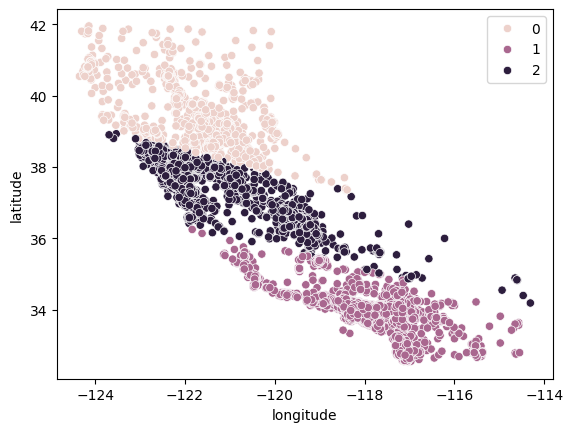

In [32]:
sns.scatterplot(data = X_train, x = 'longitude', y = 'latitude', hue = kmeans.labels_)

Menampilkan Boxplot

<Axes: ylabel='median_house_value'>

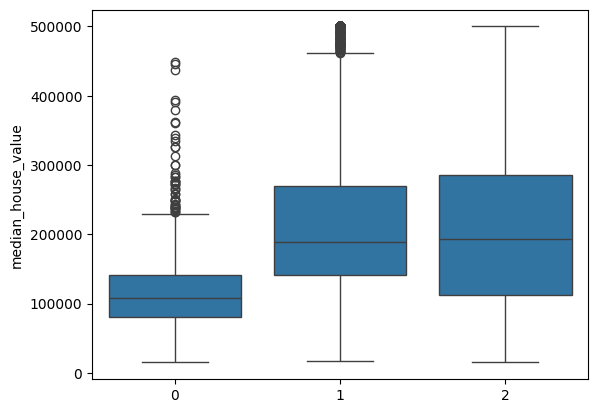

In [33]:
sns.boxplot(x = kmeans.labels_, y = y_train['median_house_value'])

Evaluasi Model

In [34]:
from sklearn.metrics import silhouette_score 
silhouette_score(X_train_norm, kmeans.labels_, metric='euclidean')

0.7491460721562756

Memilih jumlah cluster terbaik

<Axes: >

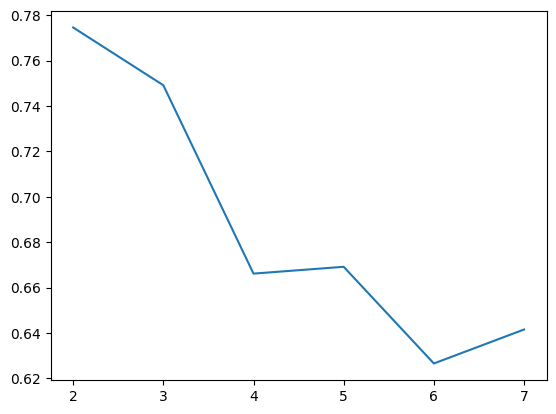

In [35]:
K = range(2, 8) 
fits = [] 
score = [] 
for k in K:
    # melatih model untuk nilai k saat ini pada data pelatihan
    model = KMeans(n_clusters=k, random_state=0, n_init='auto').fit(X_train_norm)
    # menambahkan model agar sesuai
    fits.append(model)
    # menambahkan silhouette score 
    score.append(silhouette_score(X_train_norm, 
model.labels_, metric='euclidean'))
sns.lineplot(x = K, y = score)

Menyimpan Model

In [36]:
import pickle
with open('k-means_pickle','wb') as r: pickle.dump(modelfit,r)